In [2]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne
import os
from mne.preprocessing import ICA
import ast
import sys
sys.path.append(os.path.abspath('..'))
from utils import identify_bad_channels,remove_epochs_with_bad_mmn_channels, Average_in_trials_in_time_window
import mne

mne.set_log_level('WARNING')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'


In [3]:
 
 ## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]




In [4]:
# function for statistical test 
def Average_in_trials_in_time_window(Epoches,chan, stime,etime):
    # Crop the epochs to the desired time window (100 ms to 500 ms)
    cropped_epochs =Epoches.copy().pick(chan).crop(tmin=stime, tmax=etime)
    # Initialize a dictionary to store averages for each event\]
    event_averages = {}
    # Iterate over event types
    for event_id in cropped_epochs.event_id:
        # Extract epochs for the current event
        event_epochs = cropped_epochs[event_id]
        # Calculate average for each trial across time points
        trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)
        # Store in the dictionary
        event_averages[event_id] = trial_averages
    # Example: Access the average data for a specific event
    for event, data in event_averages.items():
        print(f"Event: {event}, Averages shape: {data.shape}")
    return event_averages

# Concate all Epochs then average  for event 14,15 

### Block 1 MMN calculation

Praticipant ID:-  SD011
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  642 and in Block 2 477
Praticipant ID:-  SD012
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  501 and in Block 2 725
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  421 and in Block 2 550
Praticipant ID:-  SD013
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  730 and in Block 2 748
Praticipant ID:-  SD014
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  384 and in Block 2 388
Praticipant ID:-  SD015
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  846 and in Block 2 844


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  725 and in Block 2 705
Praticipant ID:-  SD016
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  844 and in Block 2 850
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  787 and in Block 2 601
Praticipant ID:-  SD017
Original number of epochs in Block 1  900 and in Block 2 842
After Eog rejection, number of epochs in Block 1  670 and in Block 2 631
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  599 and in Block 2 442
Praticipant ID:-  SD018
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  616 and in Block 2 640
Praticipant ID:-  SD019
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  608 and in Block 2 529
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  474 and in Block 2 471
Praticipant ID:-  SD020
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  623 and in Block 2 760
Praticipant ID:-  SD021
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  891 and in Block 2 896


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  706 and in Block 2 753
Praticipant ID:-  SD022
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  732 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  612 and in Block 2 612
Praticipant ID:-  SD023
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  321 and in Block 2 199
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  292 and in Block 2 155
Praticipant ID:-  SD024
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  578 and in Block 2 615
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  452 and in Block 2 470
Praticipant ID:-  SD025
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  862 and in Block 2 836
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  743 and in Block 2 758
Praticipant ID:-  SD026
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 885


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  526 and in Block 2 505
Praticipant ID:-  SD027
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  520 and in Block 2 585
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  479 and in Block 2 505
Praticipant ID:-  SD028
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  788 and in Block 2 528
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  583 and in Block 2 312
Praticipant ID:-  SD029
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  691 and in Block 2 616
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  669 and in Block 2 584
Praticipant ID:-  SD030
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  630 and in Block 2 602
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  616 and in Block 2 561
Praticipant ID:-  SD031
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  678 and in Block 2 621
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  600 and in Block 2 550
Praticipant ID:-  SD032
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 899
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  293 and in Block 2 247
Praticipant ID:-  SD033
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  709 and in Block 2 731
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  545 and in Block 2 590
Praticipant ID:-  SD034
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  687 and in Block 2 580
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  426 and in Block 2 391
Praticipant ID:-  SD035
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  196 and in Block 2 303
Praticipant ID:-  SD036
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  487 and in Block 2 390
Praticipant ID:-  SD037
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  898 and in Block 2 900
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  369 and in Block 2 229
Praticipant ID:-  SD038
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  227 and in Block 2 164
NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  134 and in Block 2 81
Praticipant ID:-  SD039


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  853 and in Block 2 816


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  737 and in Block 2 703
Praticipant ID:-  SD040
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  888 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  442 and in Block 2 625
Praticipant ID:-  SD041  Removed
Praticipant ID:-  SD042
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  899 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  603 and in Block 2 679
Praticipant ID:-  SD043
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  856 and in Block 2 895


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  114 and in Block 2 175
Praticipant ID:-  SD044
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  482 and in Block 2 455
Praticipant ID:-  SD045
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  887 and in Block 2 837


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  487 and in Block 2 396
Praticipant ID:-  SD046  Removed
Praticipant ID:-  SD047
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  722 and in Block 2 710


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  507 and in Block 2 460
Praticipant ID:-  SD048
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  893 and in Block 2 897


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  343 and in Block 2 728
Praticipant ID:-  SD049
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  881 and in Block 2 894


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  532 and in Block 2 745
Praticipant ID:-  SD050
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  797 and in Block 2 724


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  659 and in Block 2 643
Praticipant ID:-  SD051
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  48 and in Block 2 157
Praticipant ID:-  SD052  Removed
Praticipant ID:-  SD053
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 899


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  603 and in Block 2 521
Praticipant ID:-  SD054
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  892 and in Block 2 843


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  8 and in Block 2 60
Praticipant ID:-  SD055
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  387 and in Block 2 551
Praticipant ID:-  SD056
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  449 and in Block 2 342
Praticipant ID:-  SD057
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:46: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  868 and in Block 2 872


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  304 and in Block 2 282
Praticipant ID:-  SD058  Removed
Praticipant ID:-  SD059
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 860


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  75 and in Block 2 87
Praticipant ID:-  SD060
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  610 and in Block 2 638


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  577 and in Block 2 625
Praticipant ID:-  SD061
Original number of epochs in Block 1  900 and in Block 2 974
After Eog rejection, number of epochs in Block 1  900 and in Block 2 974


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  571 and in Block 2 698
Praticipant ID:-  SD062
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  756 and in Block 2 752


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  238 and in Block 2 336
Praticipant ID:-  SD063
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  713 and in Block 2 716
Praticipant ID:-  SD064
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  899 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  417 and in Block 2 286
Praticipant ID:-  SD065
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 899


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  115 and in Block 2 110
Praticipant ID:-  SD066
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  830 and in Block 2 870


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  229 and in Block 2 390
Praticipant ID:-  SD067
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  756 and in Block 2 336


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4200631266.py:74: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  B1_all_epochs = mne.concatenate_epochs(B1_all_epochs_list)


After Bad epoch rejection,  number of epochs in Block 1 standard 20959 and deviant 4166


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)


Event: 14, Averages shape: (20959, 1)
Event: 15, Averages shape: (4166, 1)


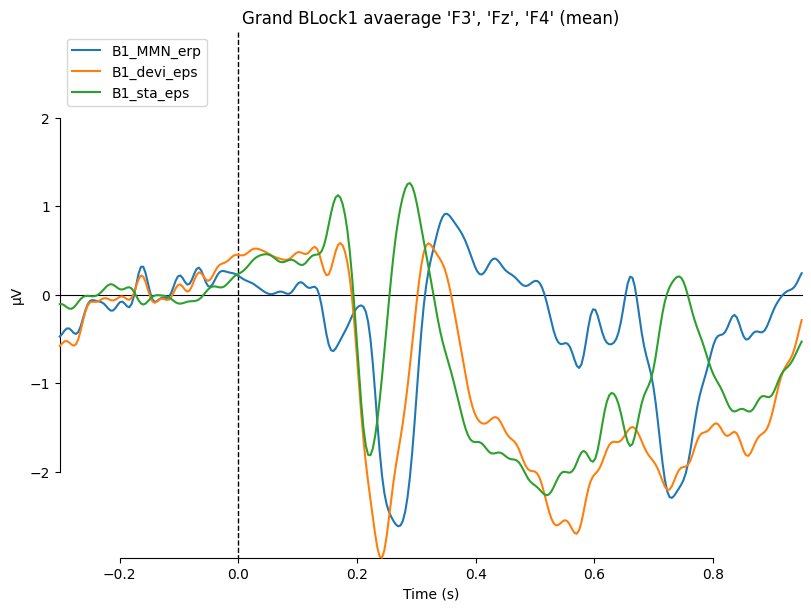

'After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861'

In [5]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"

subjects = [sub for sub in os.listdir(data_folder) if (("SD" in sub) & (os.path.isdir(os.path.join(data_folder,sub))))]
data_type = "EEG"
 # it is useful to scroll eeg data 
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
B1_all_epochs_list =[]
B2_all_epochs_list =[]
for sub in subjects: 
    path = os.path.join(data_folder,sub,data_type)
    if   sub   in  ['SD041','SD046','SD052','SD058']:
                print("Praticipant ID:- ", sub," Removed" )
                continue
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
            print("Praticipant ID:- ", sub )
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter
            raw.resample(256) 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.9500,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.9500,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels = [ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            try:
                cleaned_epochs.drop_channels(['GSR', 'PPG'])
            except:
                print("NO PPG sensor")
                pass
            print(f"After Bad epoch rejection,  number of epochs in Block 1  {len(cleaned_epochs['14','15'])} and in Block 2 {len(cleaned_epochs['24','25'])}")
            # Append the subject's epochs to the list
            """B1_sta_all_epochs_list.append(cleaned_epochs['14'])
            B1_devi_all_epochs_list.append(cleaned_epochs['1 5']) """
            B1_all_epochs_list.append(cleaned_epochs['14','15'])
            #B2_all_epochs_list.append(cleaned_epochs['24','25'])



 

B1_all_epochs = mne.concatenate_epochs(B1_all_epochs_list)


print(f"After Bad epoch rejection,  number of epochs in Block 1 standard {len(B1_all_epochs['14'])} and deviant {len(B1_all_epochs['15'])}")
B1_devi_eps = B1_all_epochs['15'].average()
B1_sta_eps = B1_all_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
##  Statistical significance 
B1_avg_stat = Average_in_trials_in_time_window(B1_all_epochs,chan="Cz", stime=.430,etime = .530)
#picks = [n for n in range(1, 5)]
picks= ['F3', 'Fz', 'F4',] 
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861"""


### Block 2 MMN calculation 

Praticipant ID:-  SD011
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  642 and in Block 2 477
Praticipant ID:-  SD012
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  501 and in Block 2 725


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  421 and in Block 2 550
Praticipant ID:-  SD013
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  730 and in Block 2 748
Praticipant ID:-  SD014
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  384 and in Block 2 388
Praticipant ID:-  SD015
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  846 and in Block 2 844


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  725 and in Block 2 705
Praticipant ID:-  SD016
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  798 and in Block 2 779


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  747 and in Block 2 555
Praticipant ID:-  SD017
Original number of epochs in Block 1  900 and in Block 2 842
After Eog rejection, number of epochs in Block 1  670 and in Block 2 631


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  599 and in Block 2 442
Praticipant ID:-  SD018
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  616 and in Block 2 640
Praticipant ID:-  SD019
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  608 and in Block 2 529
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  474 and in Block 2 471
Praticipant ID:-  SD020
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  623 and in Block 2 760
Praticipant ID:-  SD021
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  891 and in Block 2 896


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  706 and in Block 2 753
Praticipant ID:-  SD022
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  732 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  612 and in Block 2 612
Praticipant ID:-  SD023
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  321 and in Block 2 199
NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  292 and in Block 2 155


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Praticipant ID:-  SD024
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  578 and in Block 2 615
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  452 and in Block 2 470
Praticipant ID:-  SD025
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  862 and in Block 2 836


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  743 and in Block 2 758
Praticipant ID:-  SD026
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 885


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  526 and in Block 2 505
Praticipant ID:-  SD027
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  520 and in Block 2 585
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  479 and in Block 2 505
Praticipant ID:-  SD028
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  788 and in Block 2 528


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  583 and in Block 2 312
Praticipant ID:-  SD029
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  691 and in Block 2 616


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  669 and in Block 2 584
Praticipant ID:-  SD030
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  630 and in Block 2 602
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  616 and in Block 2 561
Praticipant ID:-  SD031
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  678 and in Block 2 621
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  600 and in Block 2 550
Praticipant ID:-  SD032
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 899


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  293 and in Block 2 247
Praticipant ID:-  SD033
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  709 and in Block 2 731


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  545 and in Block 2 590
Praticipant ID:-  SD034
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  687 and in Block 2 580


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  426 and in Block 2 391
Praticipant ID:-  SD035
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  196 and in Block 2 303
Praticipant ID:-  SD036
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  487 and in Block 2 390
Praticipant ID:-  SD037
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  898 and in Block 2 900
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  369 and in Block 2 229
Praticipant ID:-  SD038
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  227 and in Block 2 164
NO PPG sensor
After Bad epoch rejection,  number of epochs in Block 1  134 and in Block 2 81
Praticipant ID:-  SD039


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  853 and in Block 2 815
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  737 and in Block 2 702
Praticipant ID:-  SD040
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  888 and in Block 2 898
NO PPG sensor


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  442 and in Block 2 625
Praticipant ID:-  SD041  Removed.
Praticipant ID:-  SD042
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  899 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  603 and in Block 2 679
Praticipant ID:-  SD043
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  856 and in Block 2 895


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  114 and in Block 2 175
Praticipant ID:-  SD044
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  482 and in Block 2 455
Praticipant ID:-  SD045
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  887 and in Block 2 837


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  487 and in Block 2 396
Praticipant ID:-  SD046  Removed.
Praticipant ID:-  SD047
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  722 and in Block 2 709


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  507 and in Block 2 460
Praticipant ID:-  SD048
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  893 and in Block 2 897


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  343 and in Block 2 728
Praticipant ID:-  SD049
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  881 and in Block 2 894


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  532 and in Block 2 745
Praticipant ID:-  SD050
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  797 and in Block 2 724


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  659 and in Block 2 643
Praticipant ID:-  SD051
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  48 and in Block 2 157
Praticipant ID:-  SD052  Removed.
Praticipant ID:-  SD053
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 899


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  603 and in Block 2 521
Praticipant ID:-  SD054
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  892 and in Block 2 843
After Bad epoch rejection,  number of epochs in Block 1  8 and in Block 2 60


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Praticipant ID:-  SD055
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  387 and in Block 2 551
Praticipant ID:-  SD056
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  448 and in Block 2 342
Praticipant ID:-  SD057
Original number of epochs in Block 1  900 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:49: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


After Eog rejection, number of epochs in Block 1  868 and in Block 2 872


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  304 and in Block 2 282
Praticipant ID:-  SD058  Removed.
Praticipant ID:-  SD059
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 860


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  75 and in Block 2 87
Praticipant ID:-  SD060
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  610 and in Block 2 638


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  577 and in Block 2 625
Praticipant ID:-  SD061
Original number of epochs in Block 1  900 and in Block 2 974
After Eog rejection, number of epochs in Block 1  900 and in Block 2 974


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  571 and in Block 2 698
Praticipant ID:-  SD062
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  756 and in Block 2 752


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  238 and in Block 2 336
Praticipant ID:-  SD063
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  898 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  713 and in Block 2 716
Praticipant ID:-  SD064
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  899 and in Block 2 900


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  417 and in Block 2 286
Praticipant ID:-  SD065
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 899


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  115 and in Block 2 110
Praticipant ID:-  SD066
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  830 and in Block 2 870


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  229 and in Block 2 390
Praticipant ID:-  SD067
Original number of epochs in Block 1  900 and in Block 2 900
After Eog rejection, number of epochs in Block 1  900 and in Block 2 898


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\666514540.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


After Bad epoch rejection,  number of epochs in Block 1  756 and in Block 2 336


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4196817858.py:78: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  B2_all_epochs = mne.concatenate_epochs(B2_all_epochs_list)
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)


Event: 24, Averages shape: (20605, 1)
Event: 25, Averages shape: (4232, 1)


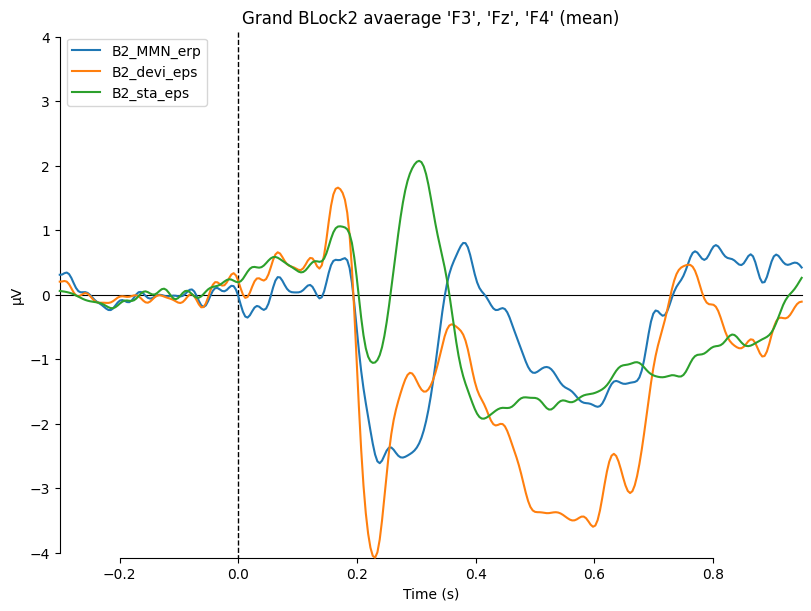

'After Bad epoch rejection,  number of epochs in Block 2 standard 13719 and deviant 2816'

In [6]:
del B1_all_epochs
del B1_all_epochs_list


data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects =  [sub for sub in os.listdir(data_folder) if (("SD" in sub) & (os.path.isdir(os.path.join(data_folder,sub))))]
data_type = "EEG"
 # it is useful to scroll eeg data 
# Create an empty list to hold epochs from all subjects 
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
#B1_all_epochs_list =[]
B2_all_epochs_list =[]
for sub in subjects:
    path = os.path.join(data_folder,sub,data_type)
    if   sub   in  ['SD041','SD046','SD052','SD058']:
                print("Praticipant ID:- ", sub," Removed." )
                continue
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
            print("Praticipant ID:- ", sub )
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            raw.resample(256)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.9500,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.9500,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels = ['Fz', 'Cz','Pz'  ]  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            try:
                cleaned_epochs.drop_channels(['GSR', 'PPG'])
            except:
                print("NO PPG sensor")
                pass

            print(f"After Bad epoch rejection,  number of epochs in Block 1  {len(cleaned_epochs['14','15'])} and in Block 2 {len(cleaned_epochs['24','25'])}")
            # Append the subject's epochs to the list
            """B1_sta_all_epochs_list.append(cleaned_epochs['14'])
            B1_devi_all_epochs_list.append(cleaned_epochs['15']) """
            #B1_all_epochs_list.append(cleaned_epochs['14','15'])
            B2_all_epochs_list.append(cleaned_epochs['24','25'])





B2_all_epochs = mne.concatenate_epochs(B2_all_epochs_list)


#print(f"After Bad epoch rejection,  number of epochs in Block 2 standard {len(B2_all_epochs['24'])} and deviant {len(B2_all_epochs['25'])}")
B2_devi_eps = B2_all_epochs['25'].average()
B2_sta_eps = B2_all_epochs["24"].average()
B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B1_sta_eps], weights=[1,-1])
evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
#picks = [n for n in range(1, 5)]
##  Statistical significance 
B2_avg_stat = Average_in_trials_in_time_window(B2_all_epochs,chan="Cz", stime=.430,etime = .530)
picks= ['F3', 'Fz', 'F4',]
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock2 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 2 standard 13719 and deviant 2816"""


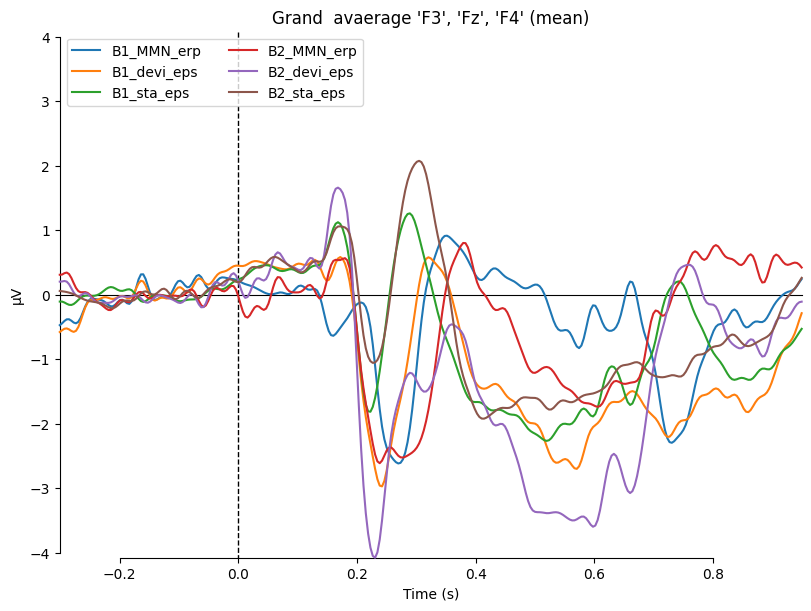

[<Figure size 800x600 with 1 Axes>]

In [7]:

del B2_all_epochs
del B2_all_epochs_list
picks = ['F3', 'Fz', 'F4']
MMN_evokeds = dict(B1_MMN_erp =B1_MMN_erp, 
                   B1_devi_eps= B1_devi_eps,   
                   B1_sta_eps=B1_sta_eps,
                   B2_MMN_erp =B2_MMN_erp, 
                   B2_devi_eps= B2_devi_eps,
                   B2_sta_eps=B2_sta_eps)  
mne.viz.plot_compare_evokeds(MMN_evokeds, picks=picks, title  = "Grand  avaerage 'F3', 'Fz', 'F4'",combine="mean")

### Personailed audio related ERP

In [8]:
def get_latency_amp(evokeds,tmin, tmax,channels = picks):
    peak_data = {}
    for name, evoked in evokeds.items():
        evoked_fz = evoked.copy().pick(picks)
        # Retrieve the latency (time), amplitude, and channel where the peak occurs
        peak_channel, peak_time, peak_amplitude,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
        peak_data[name] = {
            'Channel': peak_channel,  # channel where peak occurs
            'Latency (s)': peak_time,  # latency of peak
            'Amplitude (µV)': peak_amplitude  # amplitude of peak
            }
    return peak_data

def get_latency_amp_each_chn(evokeds,tmin, tmax,channels):
    peak_data = {}
    for name, evoked in evokeds.items():
        peak_data[name] = {}
        for ch in channels:
            evoked_fz = evoked.copy()
            evoked_fz =evoked_fz.pick([str(ch)])
            # Retrieve the latency (time), amplitude, and channel where the peak occurs
            try:
                peak_channel, peak_time_p, peak_amplitude_p,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='pos', return_amplitude=True)
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, round( peak_amplitude_p*1e6,3)))})
            except:
                (peak_time_p, peak_amplitude_p)= ("Na", 'Na')
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, peak_amplitude_p))}) 
            try:
                peak_channel, peak_time_n, peak_amplitude_n,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, round(peak_amplitude_n*1e6,3)))})
            except:
                (peak_time_n, peak_amplitude_n)= ("Na", 'Na')
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, peak_amplitude_n))}) 
            
    return peak_data


# Plot positive peak 
def plot_pos_peak(str_tuple,axes):
    pos_peak = ast.literal_eval(str_tuple)
    axes.scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
    axes.text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')
# Plot negative  peak 
def plot_neg_peak(str_tuple,axes):
    neg_peak = ast.literal_eval(str_tuple)
    axes.scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
    axes.text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')

latency_amps = []

In [9]:
# Personailzed audio related ERP 
Personalized_MMN_erp = mne.combine_evoked([ B1_MMN_erp,B2_MMN_erp], weights=[1,-1])
picks  = ["Fz","Cz","Pz"]

{'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.3515625, 1.119)', 'Fz- (Latency (s),Amplitude (µV))': '(0.265625, -2.69)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3515625, 1.775)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26171875, -2.398)', 'Pz +(Latency (s),Amplitude (µV))': '(0.3515625, 0.991)', 'Pz- (Latency (s),Amplitude (µV))': '(0.24609375, -1.313)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.37890625, 0.849)', 'Fz- (Latency (s),Amplitude (µV))': '(0.2421875, -2.468)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3671875, 1.203)', 'Cz- (Latency (s),Amplitude (µV))': '(0.234375, -1.993)', 'Pz +(Latency (s),Amplitude (µV))': '(0.36328125, 0.634)', 'Pz- (Latency (s),Amplitude (µV))': '(0.3125, -0.936)'}, 'Pers. sign. ERP': {'Fz +(Latency (s),Amplitude (µV))': '(0.3203125, 2.241)', 'Fz- (Latency (s),Amplitude (µV))': '(0.26953125, -0.318)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3203125, 2.102)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26953125, -0.733)', 'Pz +(Latency (s),A

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\694927130.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\694927130.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\694927130.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


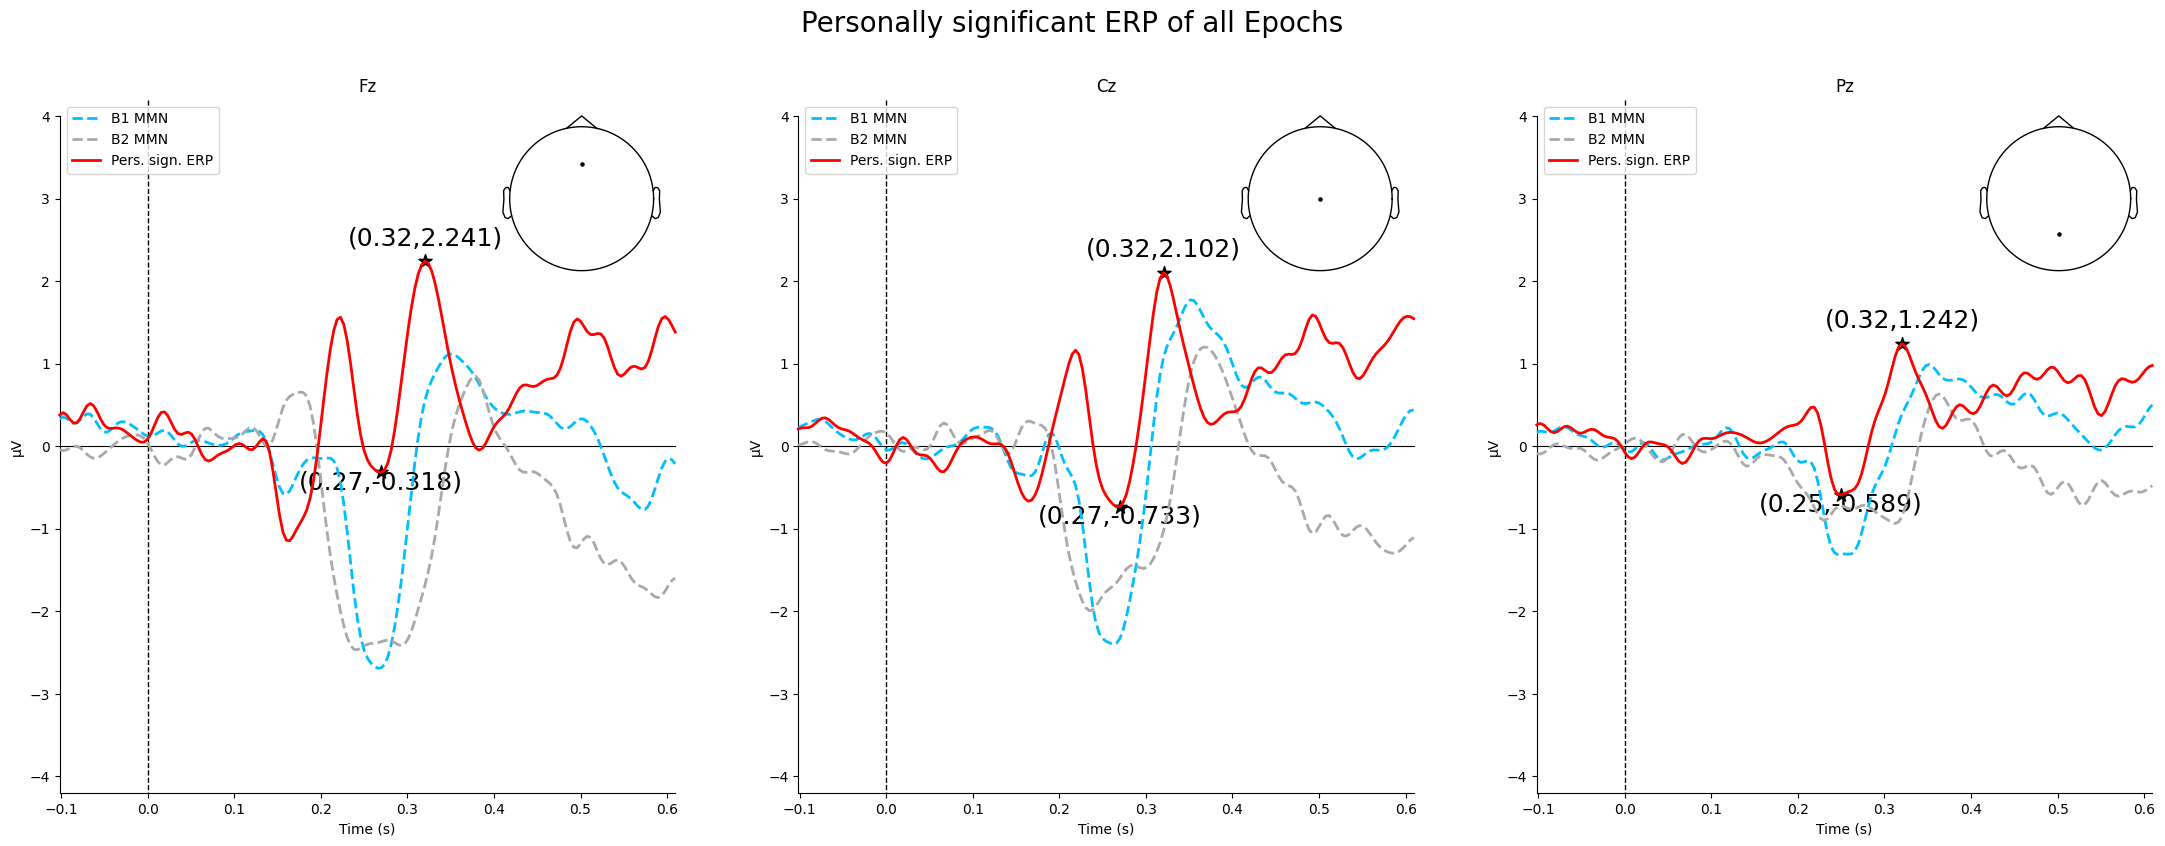

In [10]:
# PS ERp 

evokeds = {'B1 MMN': B1_MMN_erp,
           'B2 MMN': B2_MMN_erp,
           "Pers. sign. ERP" : Personalized_MMN_erp,
           }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis


stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Personally significant ERP of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### BLock 1 MMN

{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': '(0.3203125, 0.891)', 'Fz- (Latency (s),Amplitude (µV))': '(0.2421875, -2.997)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3203125, 1.506)', 'Cz- (Latency (s),Amplitude (µV))': '(0.23828125, -2.984)', 'Pz +(Latency (s),Amplitude (µV))': '(0.34375, 0.532)', 'Pz- (Latency (s),Amplitude (µV))': '(0.23828125, -1.896)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.28515625, 1.422)', 'Fz- (Latency (s),Amplitude (µV))': '(0.22265625, -1.891)', 'Cz +(Latency (s),Amplitude (µV))': '(0.28515625, 1.273)', 'Cz- (Latency (s),Amplitude (µV))': '(0.22265625, -1.715)', 'Pz +(Latency (s),Amplitude (µV))': '(0.29296875, 0.342)', 'Pz- (Latency (s),Amplitude (µV))': '(0.22265625, -0.962)'}, 'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.3515625, 1.119)', 'Fz- (Latency (s),Amplitude (µV))': '(0.265625, -2.69)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3515625, 1.775)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26171875, -2.398)', 'Pz

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031759625.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031759625.py:39: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031759625.py:42: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


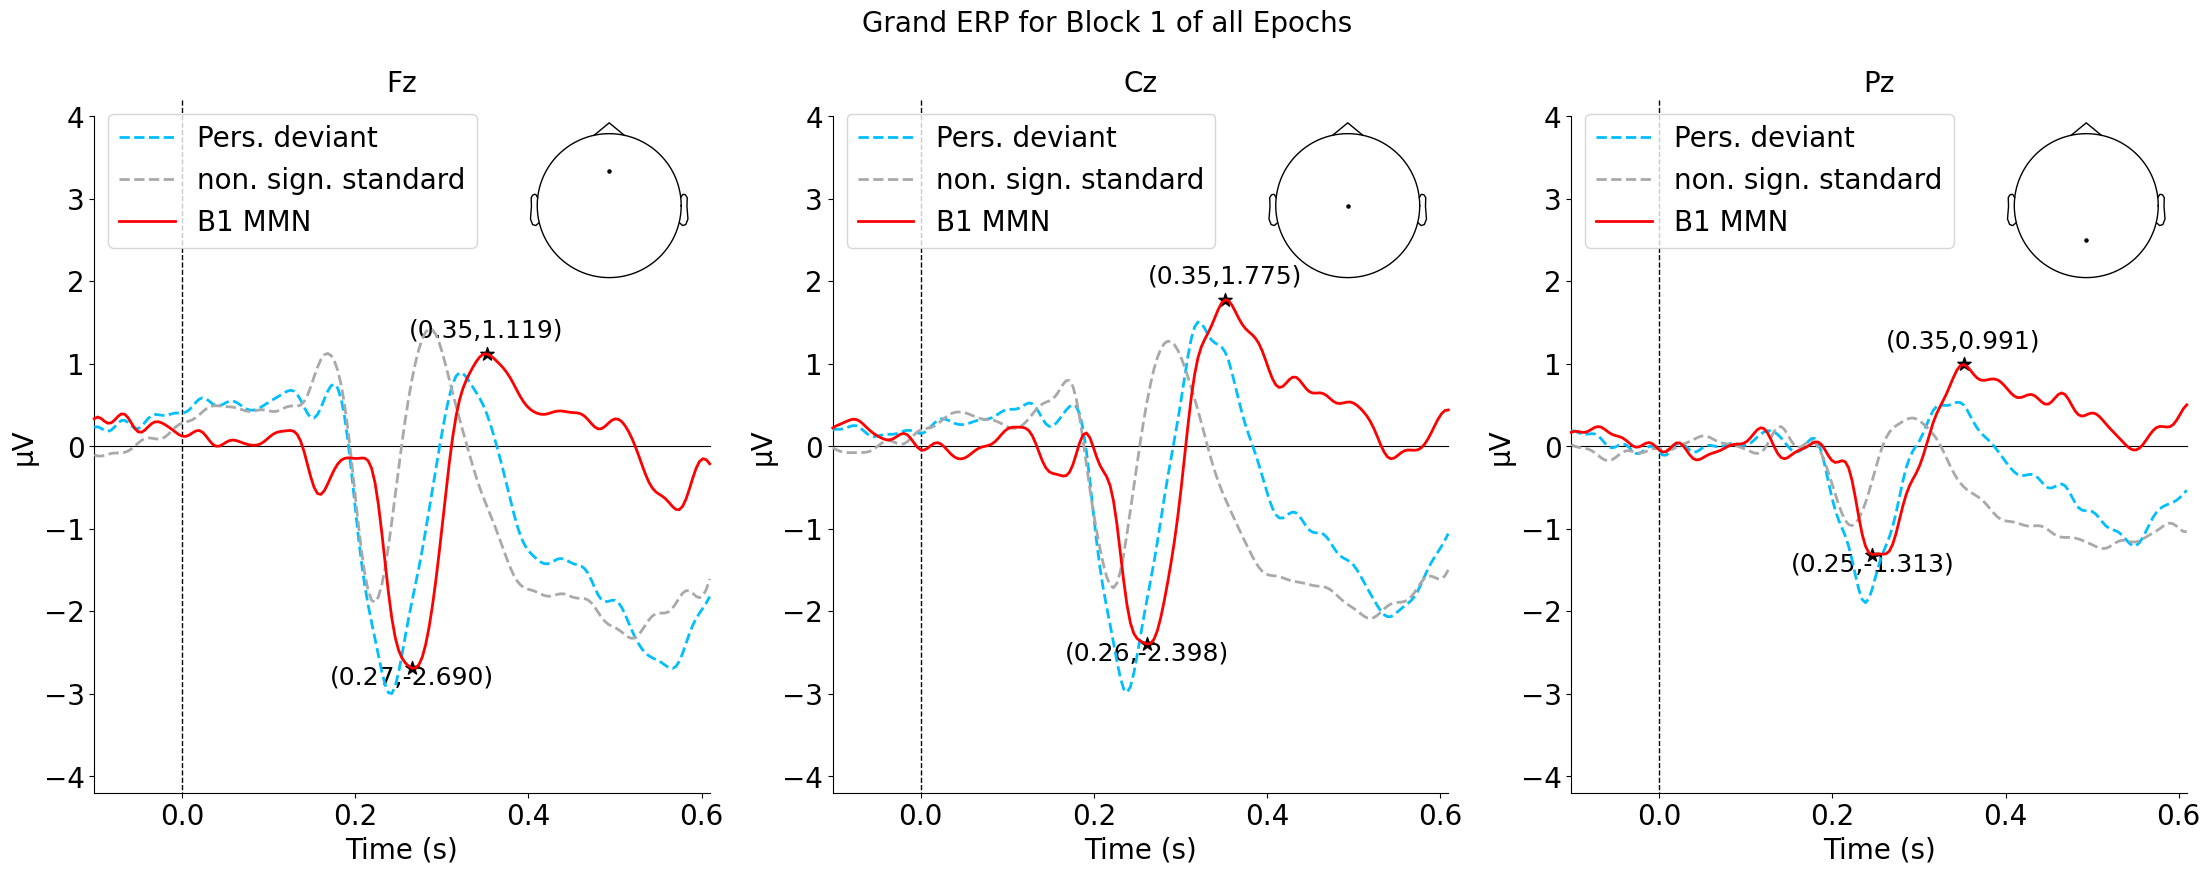

In [11]:
import mne
import matplotlib.pyplot as plt

# Assuming you have a dictionary of Evoked objects 'evokeds'
evokeds = {'Pers. deviant': B1_devi_eps,
           'non. sign. standard': B1_sta_eps,
           "B1 MMN" : B1_MMN_erp,
           }


# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "B1 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

plot_pos_peak(laten_data["B1 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["B1 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["B1 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["B1 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["B1 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["B1 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Block 1 of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### BLock 2 ERP 

{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.2265625, -4.005)', 'Cz +(Latency (s),Amplitude (µV))': '(0.359375, 0.314)', 'Cz- (Latency (s),Amplitude (µV))': '(0.2265625, -3.541)', 'Pz +(Latency (s),Amplitude (µV))': '(0.359375, 0.06)', 'Pz- (Latency (s),Amplitude (µV))': '(0.2265625, -1.816)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.30078125, 2.237)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3984375, -1.923)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3046875, 2.201)', 'Cz- (Latency (s),Amplitude (µV))': '(0.3984375, -1.466)', 'Pz +(Latency (s),Amplitude (µV))': '(0.30859375, 0.825)', 'Pz- (Latency (s),Amplitude (µV))': '(0.23046875, -0.827)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.37890625, 0.849)', 'Fz- (Latency (s),Amplitude (µV))': '(0.2421875, -2.468)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3671875, 1.203)', 'Cz- (Latency (s),Amplitude (µV))': '(0.234375, -1.993)', 'Pz +(Latency 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031697482.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031697482.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\4031697482.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


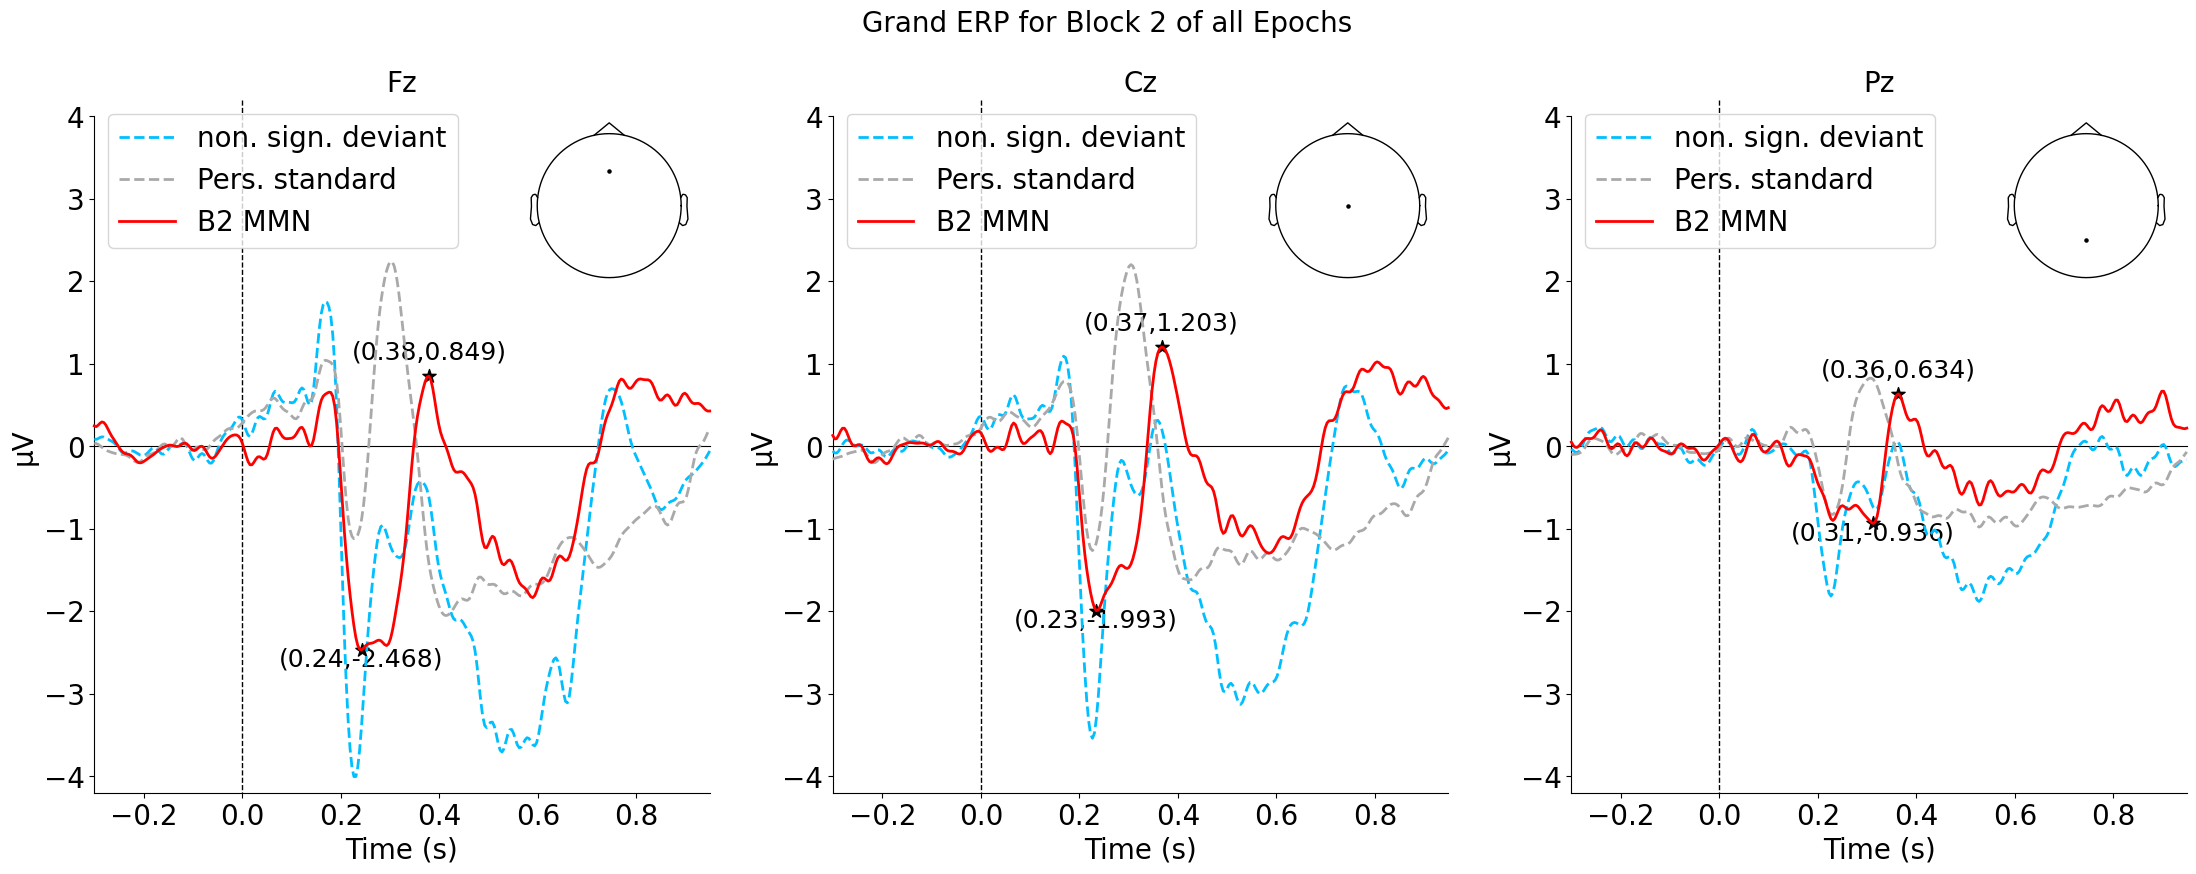

In [12]:
# Block 2 MMN
evokeds = {'non. sign. deviant': B2_devi_eps,
           'Pers. standard': B2_sta_eps,
           "B2 MMN" : B2_MMN_erp,
           }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.9
# End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

stylesdict ={'non. sign. deviant': {"linewidth": 2,"linestyle":'--'},
             'Pers. standard': {"linewidth": 2,"linestyle":'--'},
            "B2 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["B2 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["B2 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["B2 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["B2 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Block 2 of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

In [13]:
import pandas as pd
def latency_amps_to_df(dic):
    p_df = pd.DataFrame()
    for cond in dic.keys():
        df= pd.DataFrame.from_dict(dic[cond],orient='index')
        p_df = pd.concat([p_df, df],axis= 1)
    print(p_df.columns)
    p_df.columns = dic.keys()
    return p_df.T

latency_amps_to_df(latency_amps[0])


Index([0, 0, 0], dtype='int64')


,"Fz +(Latency (s),Amplitude (µV))","Fz- (Latency (s),Amplitude (µV))","Cz +(Latency (s),Amplitude (µV))","Cz- (Latency (s),Amplitude (µV))","Pz +(Latency (s),Amplitude (µV))","Pz- (Latency (s),Amplitude (µV))"
B1 MMN,"(0.3515625, 1.119)","(0.265625, -2.69)","(0.3515625, 1.775)","(0.26171875, -2.398)","(0.3515625, 0.991)","(0.24609375, -1.313)"
B2 MMN,"(0.37890625, 0.849)","(0.2421875, -2.468)","(0.3671875, 1.203)","(0.234375, -1.993)","(0.36328125, 0.634)","(0.3125, -0.936)"
Pers. sign. ERP,"(0.3203125, 2.241)","(0.26953125, -0.318)","(0.3203125, 2.102)","(0.26953125, -0.733)","(0.3203125, 1.242)","(0.25, -0.589)"


In [14]:


peak_df = pd.DataFrame.from_dict(latency_amps[0],orient='index')
for dicts in latency_amps[1:]:
    #Convert the new data dictionary to a DataFrame
    df = pd.DataFrame.from_dict(dicts, orient='index')
    # Concatenate the existing DataFrame with the new DataFrame
    peak_df = pd.concat([peak_df, df])

peak_df

,"Fz +(Latency (s),Amplitude (µV))","Fz- (Latency (s),Amplitude (µV))","Cz +(Latency (s),Amplitude (µV))","Cz- (Latency (s),Amplitude (µV))","Pz +(Latency (s),Amplitude (µV))","Pz- (Latency (s),Amplitude (µV))"
B1 MMN,"(0.3515625, 1.119)","(0.265625, -2.69)","(0.3515625, 1.775)","(0.26171875, -2.398)","(0.3515625, 0.991)","(0.24609375, -1.313)"
B2 MMN,"(0.37890625, 0.849)","(0.2421875, -2.468)","(0.3671875, 1.203)","(0.234375, -1.993)","(0.36328125, 0.634)","(0.3125, -0.936)"
Pers. sign. ERP,"(0.3203125, 2.241)","(0.26953125, -0.318)","(0.3203125, 2.102)","(0.26953125, -0.733)","(0.3203125, 1.242)","(0.25, -0.589)"
Pers. deviant,"(0.3203125, 0.891)","(0.2421875, -2.997)","(0.3203125, 1.506)","(0.23828125, -2.984)","(0.34375, 0.532)","(0.23828125, -1.896)"
non. sign. standard,"(0.28515625, 1.422)","(0.22265625, -1.891)","(0.28515625, 1.273)","(0.22265625, -1.715)","(0.29296875, 0.342)","(0.22265625, -0.962)"
B1 MMN,"(0.3515625, 1.119)","(0.265625, -2.69)","(0.3515625, 1.775)","(0.26171875, -2.398)","(0.3515625, 0.991)","(0.24609375, -1.313)"
non. sign. deviant,"('Na', 'Na')","(0.2265625, -4.005)","(0.359375, 0.314)","(0.2265625, -3.541)","(0.359375, 0.06)","(0.2265625, -1.816)"
Pers. standard,"(0.30078125, 2.237)","(0.3984375, -1.923)","(0.3046875, 2.201)","(0.3984375, -1.466)","(0.30859375, 0.825)","(0.23046875, -0.827)"
B2 MMN,"(0.37890625, 0.849)","(0.2421875, -2.468)","(0.3671875, 1.203)","(0.234375, -1.993)","(0.36328125, 0.634)","(0.3125, -0.936)"


### Personalised Deviant - Personalised standard 

{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': '(0.3203125, 0.891)', 'Fz- (Latency (s),Amplitude (µV))': '(0.2421875, -2.997)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3203125, 1.506)', 'Cz- (Latency (s),Amplitude (µV))': '(0.23828125, -2.984)', 'Pz +(Latency (s),Amplitude (µV))': '(0.34375, 0.532)', 'Pz- (Latency (s),Amplitude (µV))': '(0.23828125, -1.896)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.30078125, 2.237)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3984375, -1.923)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3046875, 2.201)', 'Cz- (Latency (s),Amplitude (µV))': '(0.3984375, -1.466)', 'Pz +(Latency (s),Amplitude (µV))': '(0.30859375, 0.825)', 'Pz- (Latency (s),Amplitude (µV))': '(0.23046875, -0.827)'}, 'persoanl MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.375, 0.787)', 'Fz- (Latency (s),Amplitude (µV))': '(0.27734375, -2.806)', 'Cz +(Latency (s),Amplitude (µV))': '(0.37890625, 1.094)', 'Cz- (Latency (s),Amplitude (µV))': '(0.2734375, -2.43)', 'Pz +(L

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\115005589.py:30: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\115005589.py:33: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\115005589.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


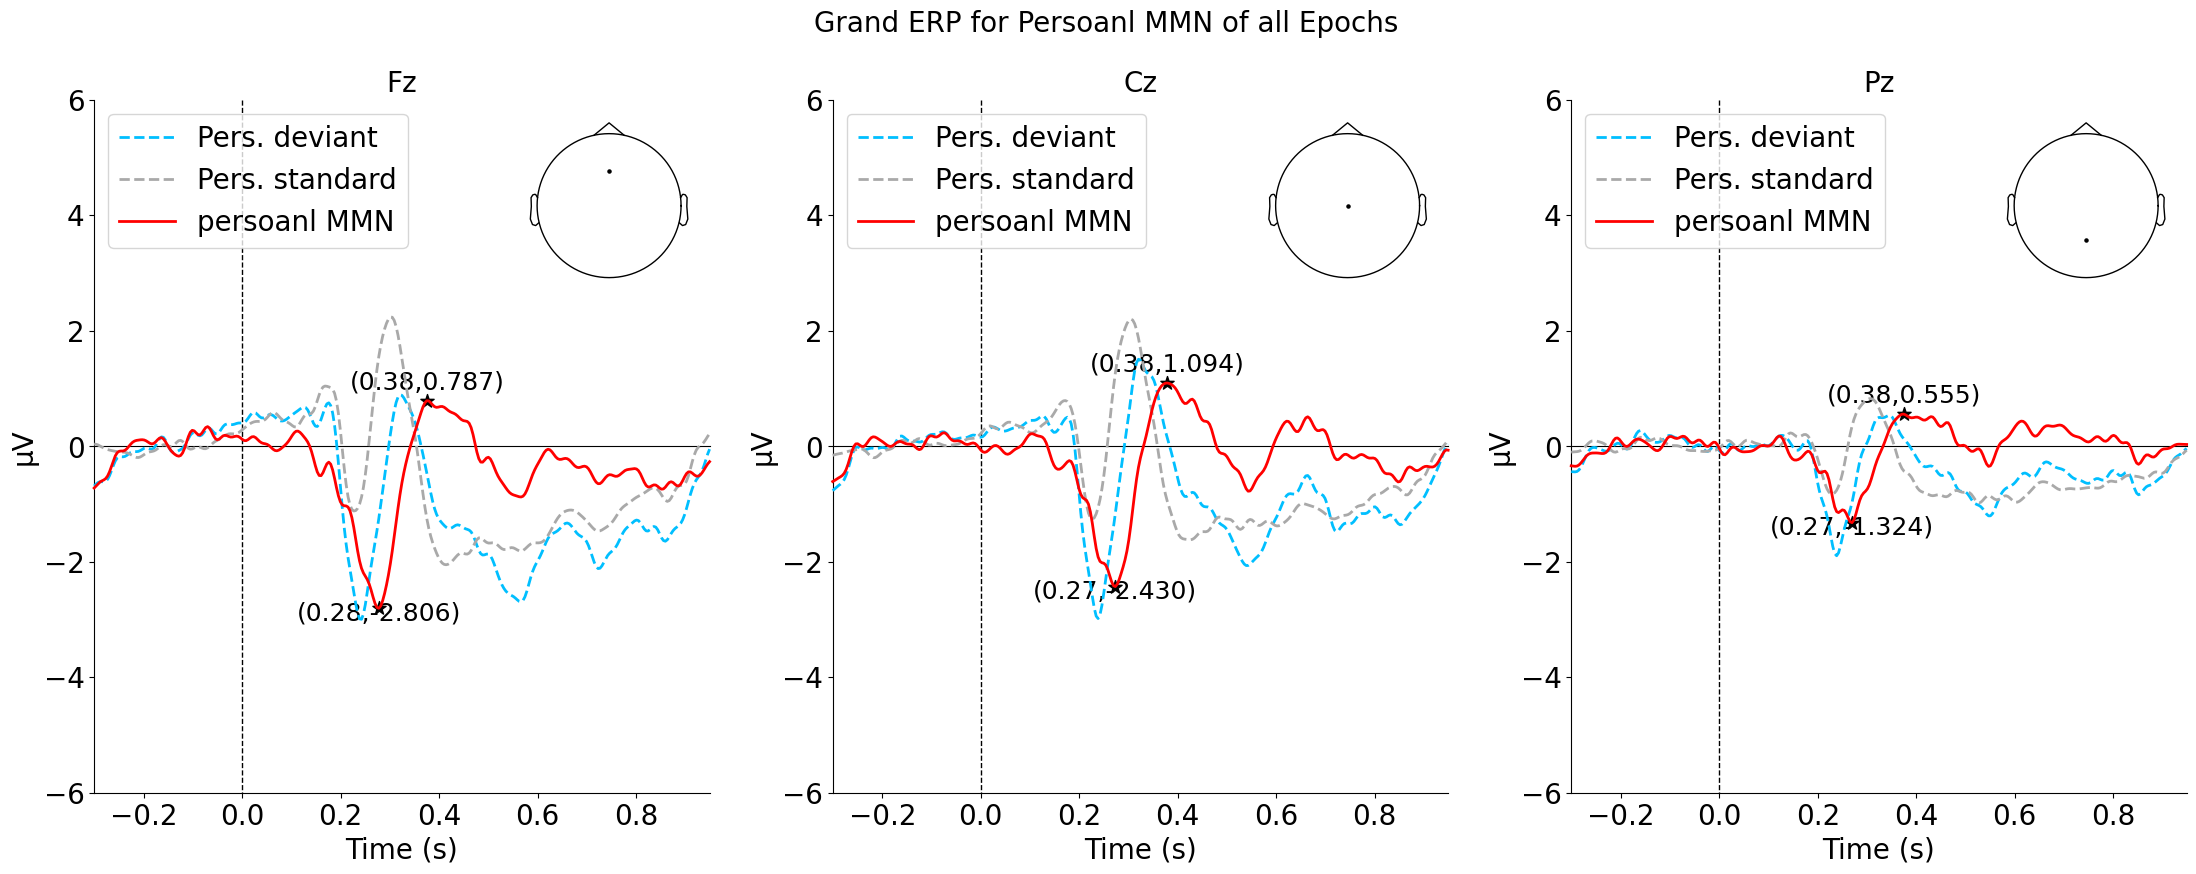

In [15]:

Personal_MMN_erp = mne.combine_evoked([B1_devi_eps,B2_sta_eps], weights=[1,-1])
evokeds = {'Pers. deviant': B1_devi_eps,
           'Pers. standard':B2_sta_eps,
           "persoanl MMN"  : Personal_MMN_erp,
           }
stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'Pers. standard': {"linewidth": 2,"linestyle":'--'},
             "persoanl MMN" : {"linewidth": 2,"linestyle":'solid'},
             }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6, 6]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["persoanl MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["persoanl MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["persoanl MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["persoanl MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["persoanl MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["persoanl MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for Persoanl MMN of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### Non-significant deviant - Non-significant standard 

{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.2265625, -4.005)', 'Cz +(Latency (s),Amplitude (µV))': '(0.359375, 0.314)', 'Cz- (Latency (s),Amplitude (µV))': '(0.2265625, -3.541)', 'Pz +(Latency (s),Amplitude (µV))': '(0.359375, 0.06)', 'Pz- (Latency (s),Amplitude (µV))': '(0.2265625, -1.816)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.28515625, 1.422)', 'Fz- (Latency (s),Amplitude (µV))': '(0.22265625, -1.891)', 'Cz +(Latency (s),Amplitude (µV))': '(0.28515625, 1.273)', 'Cz- (Latency (s),Amplitude (µV))': '(0.22265625, -1.715)', 'Pz +(Latency (s),Amplitude (µV))': '(0.29296875, 0.342)', 'Pz- (Latency (s),Amplitude (µV))': '(0.22265625, -0.962)'}, 'non. sign. MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.37890625, 0.849)', 'Fz- (Latency (s),Amplitude (µV))': '(0.2421875, -2.468)', 'Cz +(Latency (s),Amplitude (µV))': '(0.3671875, 1.203)', 'Cz- (Latency (s),Amplitude (µV))': '(0.234375, -1.993)'

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1834414450.py:32: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1834414450.py:35: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1834414450.py:38: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


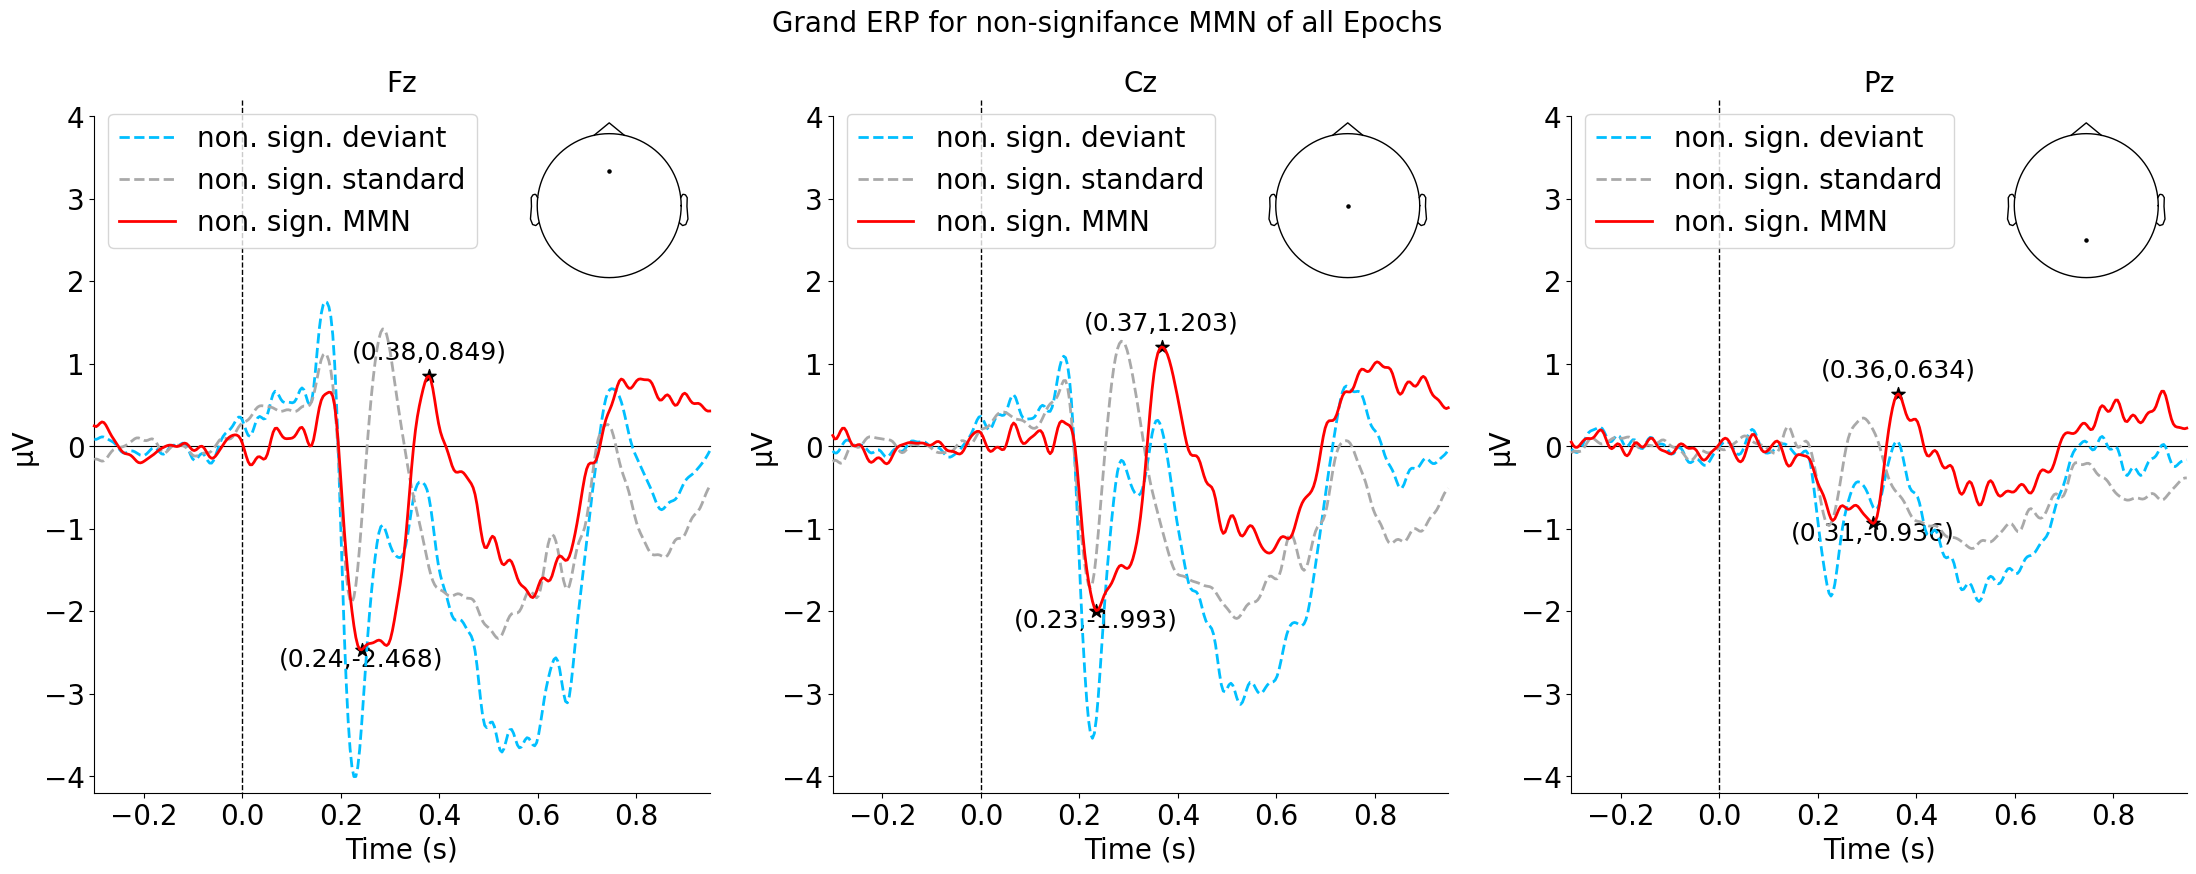

In [ ]:

non_sign_MMN_erp = mne.combine_evoked([B2_devi_eps,B1_sta_eps], weights=[1,-1])

# ### Low addiction score 
evokeds = {'non. sign. deviant': B2_devi_eps,
           'non. sign. standard':B1_sta_eps,
           "non. sign. MMN"  : non_sign_MMN_erp,
           }
stylesdict ={'non. sign. deviant': {"linewidth": 2,"linestyle":'--'}, 
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "non. sign. MMN" : {"linewidth": 2,"linestyle":'solid'},
             }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.6    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

mne.viz.plot_compare_evokeds(evokeds, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

"""neg_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'])
axs[0].scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
axs[0].text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f},{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')
pos_peak = ast.literal_eval(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'])
axs[0].scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
axs[0].text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')"""
plot_pos_peak(laten_data["non. sign. MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["non. sign. MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["non. sign. MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["non. sign. MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["non. sign. MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["non. sign. MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Grand ERP for non-signifance MMN of all Epochs', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

In [17]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'PS deviant': B1_devi_eps,
           'Non Ps deviant': B2_devi_eps,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 3, figsize=(20, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1,1]},dpi =1000)

stylesdict ={'PS deviant': {"linewidth": 3,"linestyle":'solid'},
             'Non Ps deviant' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Deviant')

# ### B1 MMN  for all the categories
evokeds = {'PS std':B2_sta_eps,
           'Non PS std': B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS std': {"linewidth": 3,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Standard')


# ### B1 MMN  for all the categories
evokeds = {'PS MMN':Personal_MMN_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS MMN': {"linewidth": 3,"linestyle":'solid'},
             'Non PS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN')

# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.75, 0.40, f"PS", transform=axs[0].transAxes, fontsize=30, color='deepskyblue')
axs[0].text( 0.75,0.20, f"Non-PS", transform=axs[0].transAxes, fontsize=30, color='darkorange')
# Add an arrow pointing to a specific point
axs[0].annotate(
    '',  # Text for the annotation
    xy=(210,-5),  # Point to annotate (x, y)
    xytext=(250, -4.5),  # Position of the text (x, y)
    arrowprops=dict(facecolor='black', arrowstyle='<-',linewidth  = 5)  # Arrow properties
)
axs[2].annotate(
    '',  # Text for the annotation
    xy=(160,4),  # Point to annotate (x, y)
    xytext=(200, 3.5),  # Position of the text (x, y)
    arrowprops=dict(facecolor='black', arrowstyle='<-',linewidth  = 5)  # Arrow properties
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2981479417.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2981479417.py:41: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2981479417.py:63: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\973626230.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\973626230.py:41: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\973626230.py:63: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


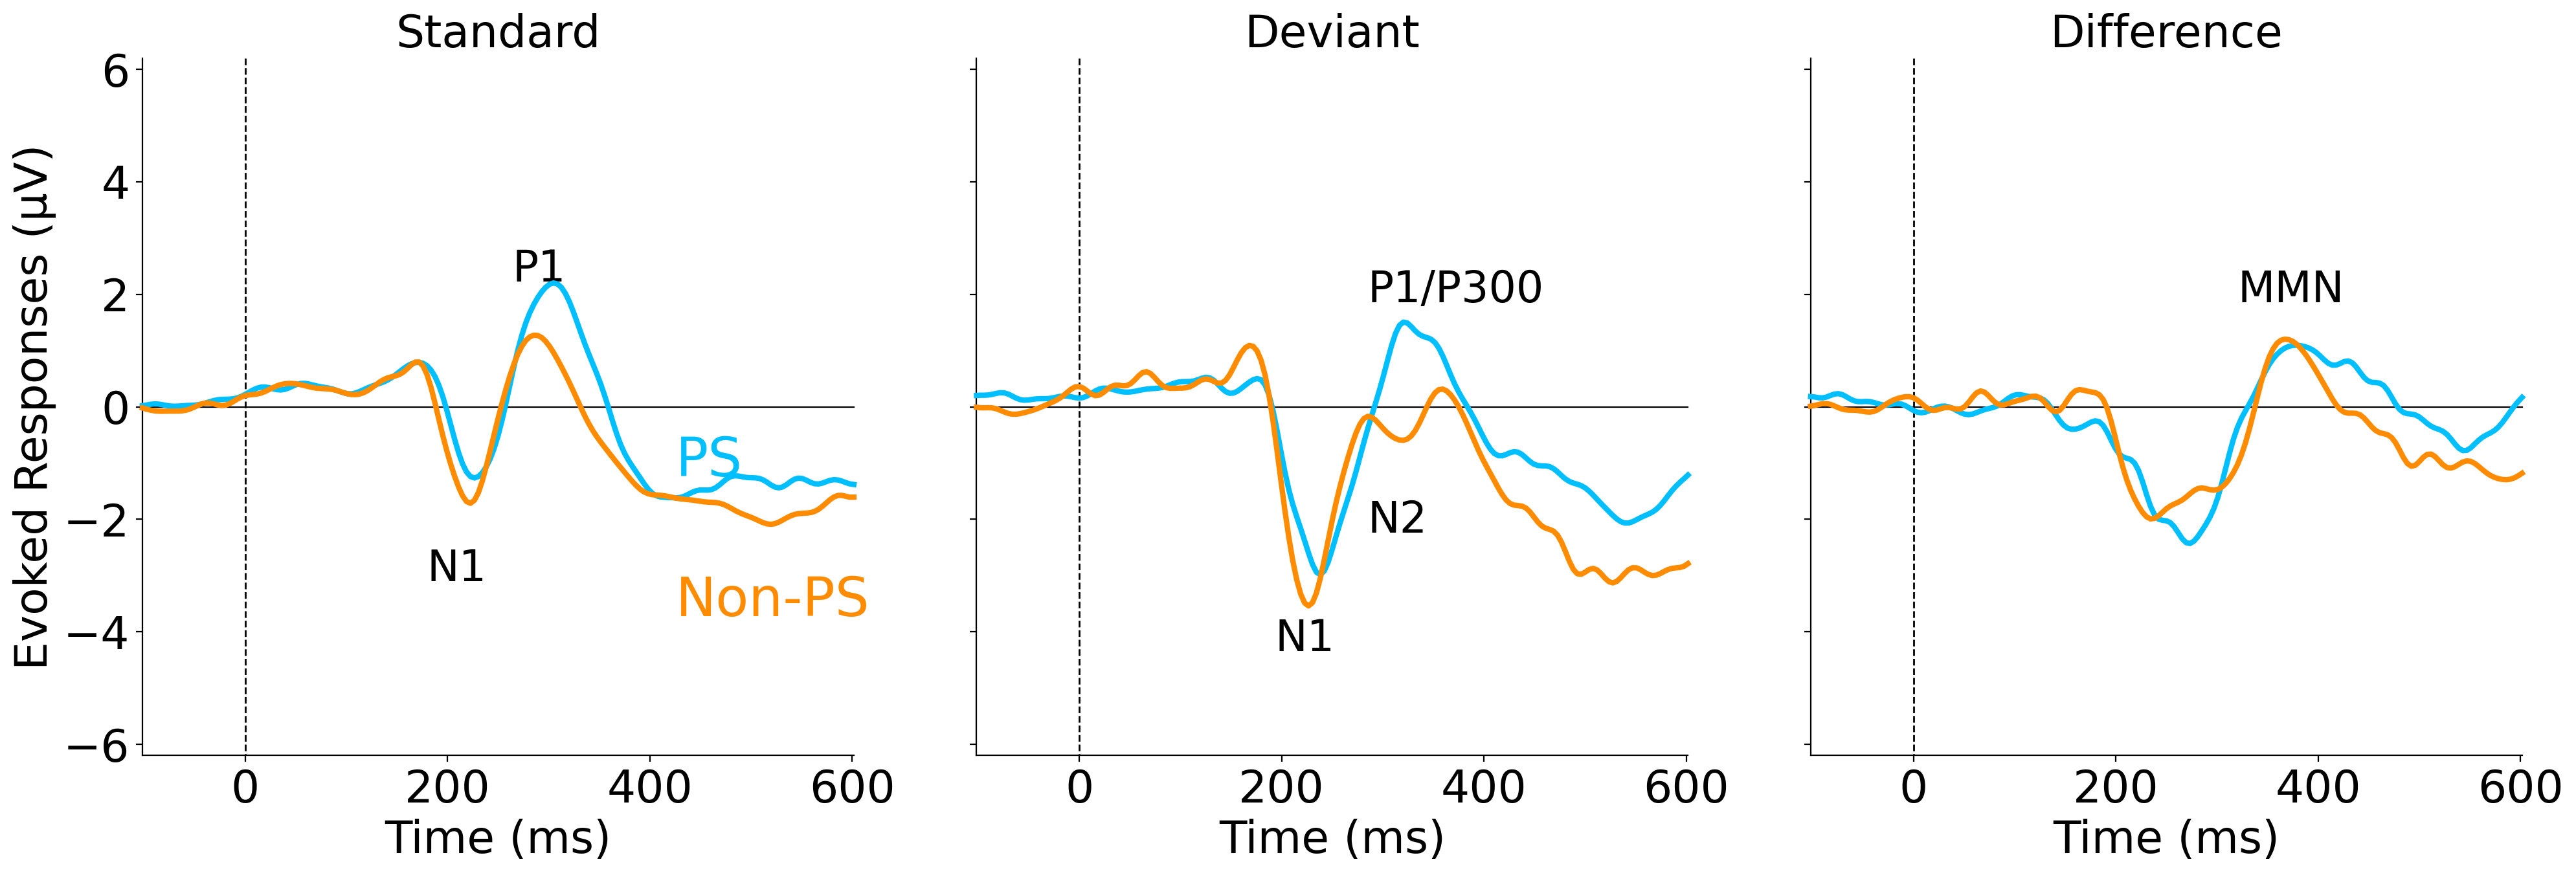

In [18]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'PS deviant': B1_devi_eps,
           'Non Ps deviant': B2_devi_eps,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 3, figsize=(20, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1,1]},dpi =200)

stylesdict ={'PS deviant': {"linewidth": 3,"linestyle":'solid'},
             'Non Ps deviant' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Deviant')

# ### B1 MMN  for all the categories
evokeds = {'PS std':B2_sta_eps,
           'Non PS std': B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS std': {"linewidth": 3,"linestyle":'solid'},
             'Non PS std' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Standard')


# ### B1 MMN  for all the categories
evokeds = {'PS MMN':Personal_MMN_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'PS MMN': {"linewidth": 3,"linestyle":'solid'},
             'Non PS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='Difference')

# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.75, 0.40, f"PS", transform=axs[0].transAxes, fontsize=30, color='deepskyblue')
axs[0].text( 0.75,0.20, f"Non-PS", transform=axs[0].transAxes, fontsize=30, color='darkorange')
# Add an arrow pointing to a specific point
axs[0].text(0.40, 0.25, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.52,0.68, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')

# Add an arrow pointing to a specific point
axs[1].text(0.42, 0.15, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')
axs[1].text(0.55, 0.32, f"N2", transform=axs[1].transAxes, fontsize=24, color='black')
axs[1].text( 0.55,0.65, f"P1/P300", transform=axs[1].transAxes, fontsize=24, color='black')
axs[2].text( 0.60,0.65, f"MMN", transform=axs[2].transAxes, fontsize=24, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1347182748.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1347182748.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\1347182748.py:73: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,


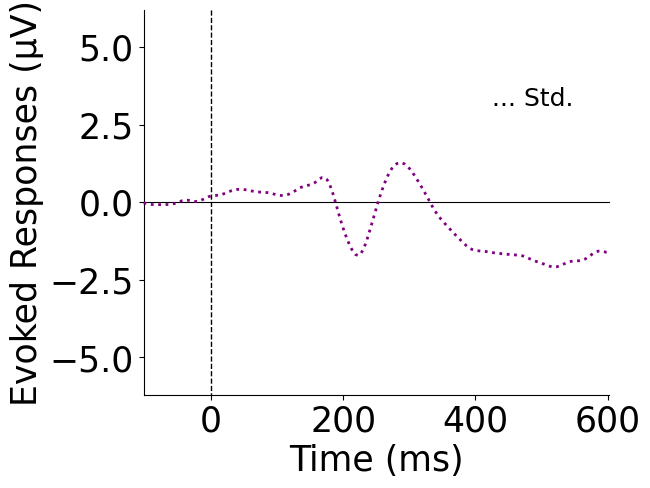

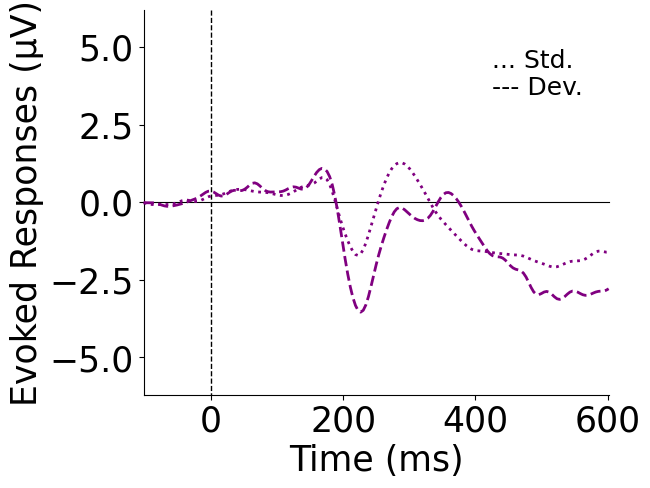

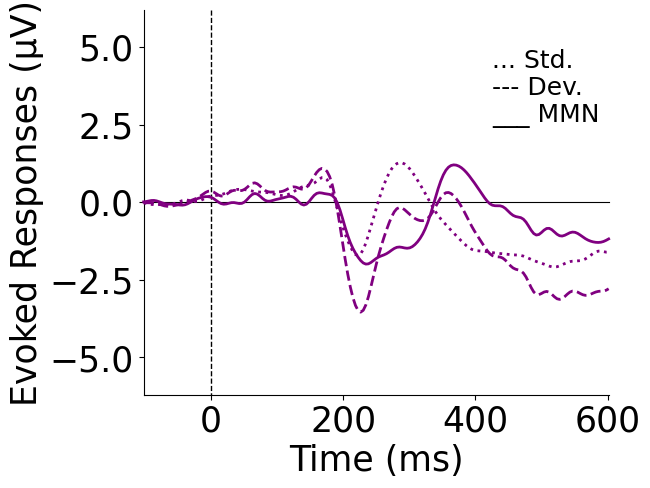

In [19]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_eps,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps,
           'Non PS std':B1_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps,
           'Non PS std':B1_sta_eps,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"___ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2994711829.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2994711829.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\2994711829.py:73: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,


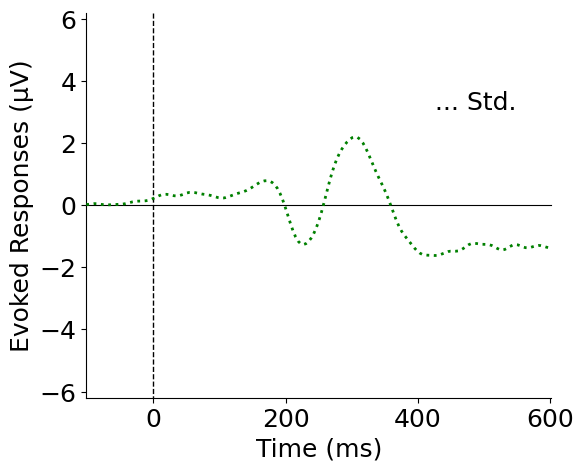

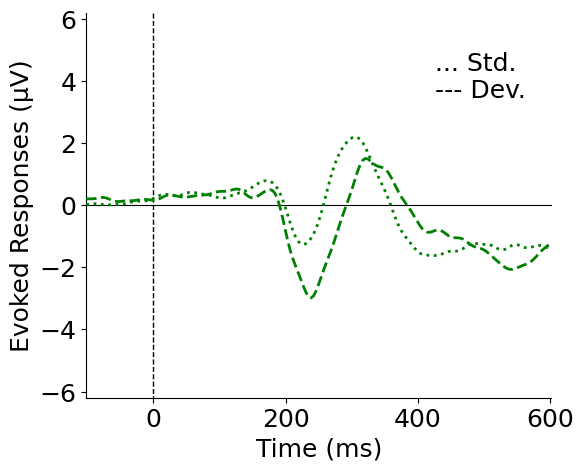

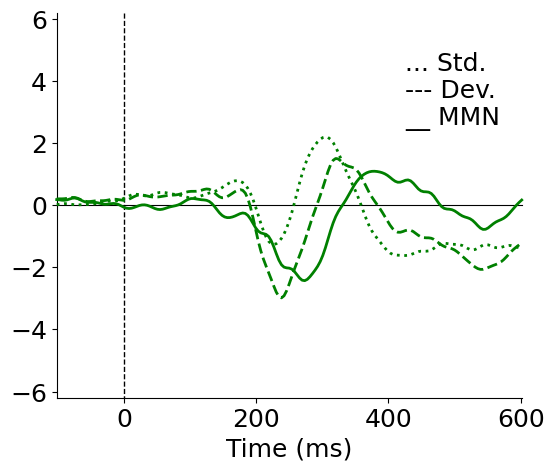

In [20]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'PS std':B2_sta_eps,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps,
           'PS std':B2_sta_eps,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object 
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps,
           'PS std':B2_sta_eps,
           'PS MMN': Personal_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"__ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\172631741.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11236\172631741.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


Text(0, 0.5, 'Evoked Responses (µV)')

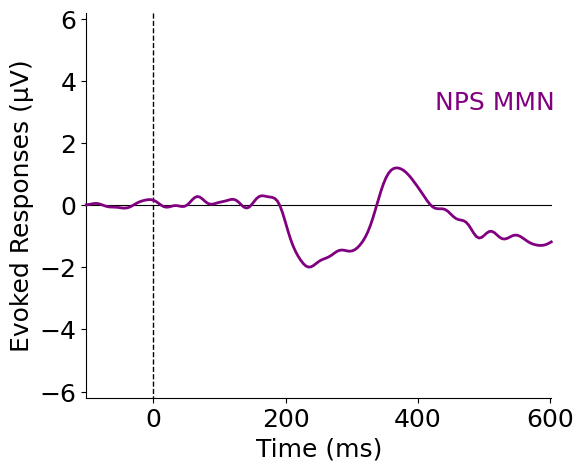

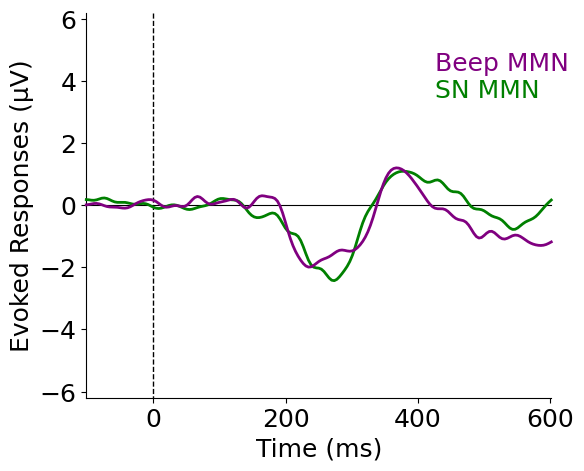

In [21]:
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'NPS MMN':non_sign_MMN_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid',},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"NPS MMN", transform=axs.transAxes, fontsize=18, color='purple')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp,
    'NPS MMN':non_sign_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses

### TOPMAP

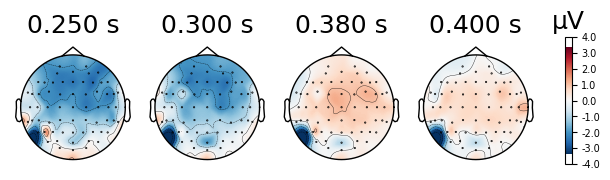

In [22]:
# Plot the scalp topography for MMN
times = np.linspace(0.1, 0.4, 5)
fig_mmn = non_sign_MMN_erp.copy().drop_channels(["AF7"]).plot_topomap(times=[0.25,0.300,.3800,.400], ch_type="eeg", show=True, time_unit='s')


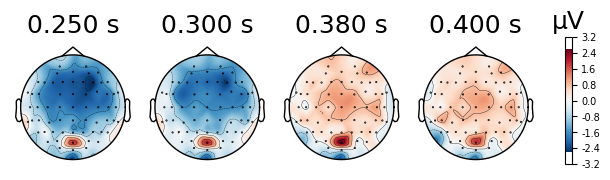

In [23]:
fig_mmn =  Personal_MMN_erp.copy().drop_channels(["AF7","FC3"]).plot_topomap(times=[0.25,0.300,.380,.400], ch_type="eeg", time_unit='s')

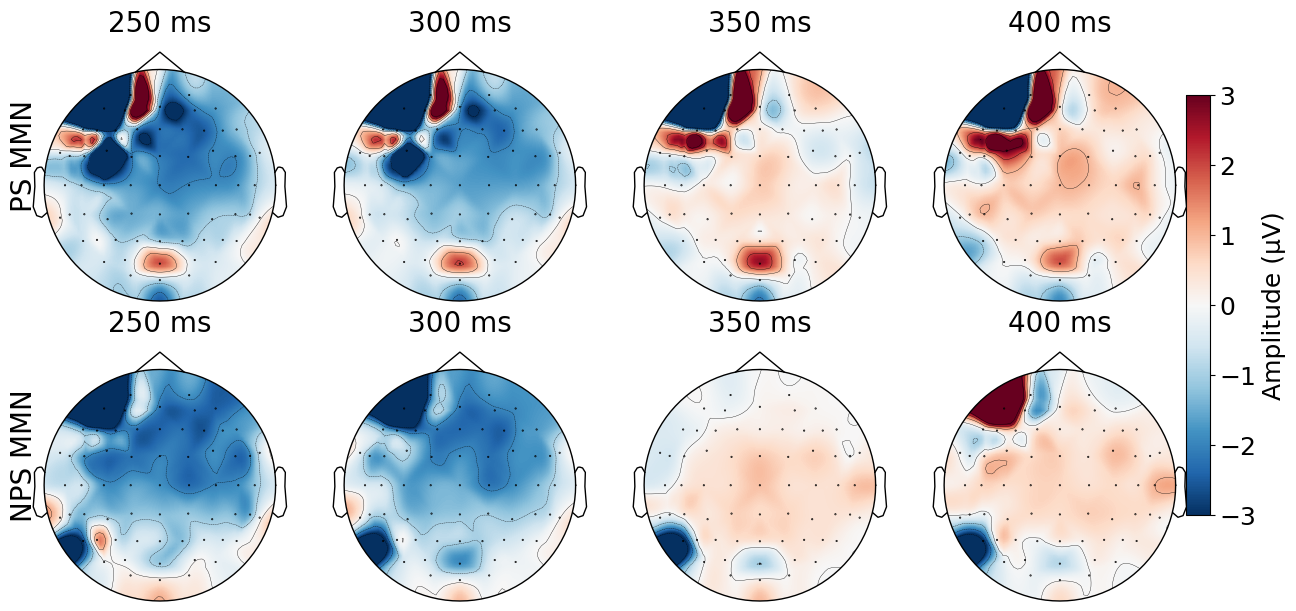

In [24]:

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [0.25, 0.30, 0.35, 0.40]

# Set the color scale range
vlim = (-3,3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(2, len(time_points), figsize=(12, 6), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    Personal_MMN_erp.copy().plot_topomap(
        times=[time], axes=axes[0, i], colorbar=False, vlim=vlim, show=False
    )
    axes[0, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Plot topomaps for the second evoked (B1_MMN_erp)
for i, time in enumerate(time_points):
    im= non_sign_MMN_erp.copy().plot_topomap(
        times=[time], axes=axes[1, i], colorbar=False, vlim=vlim, show=False
    )
    axes[1, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.02, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Amplitude (µV)')

# Add row labels
fig.text(0.0001, 0.75, 'PS MMN', fontsize=20, rotation=90, va='center')
fig.text(0.0001, 0.25, 'NPS MMN', fontsize=20, rotation=90, va='center')

plt.show()



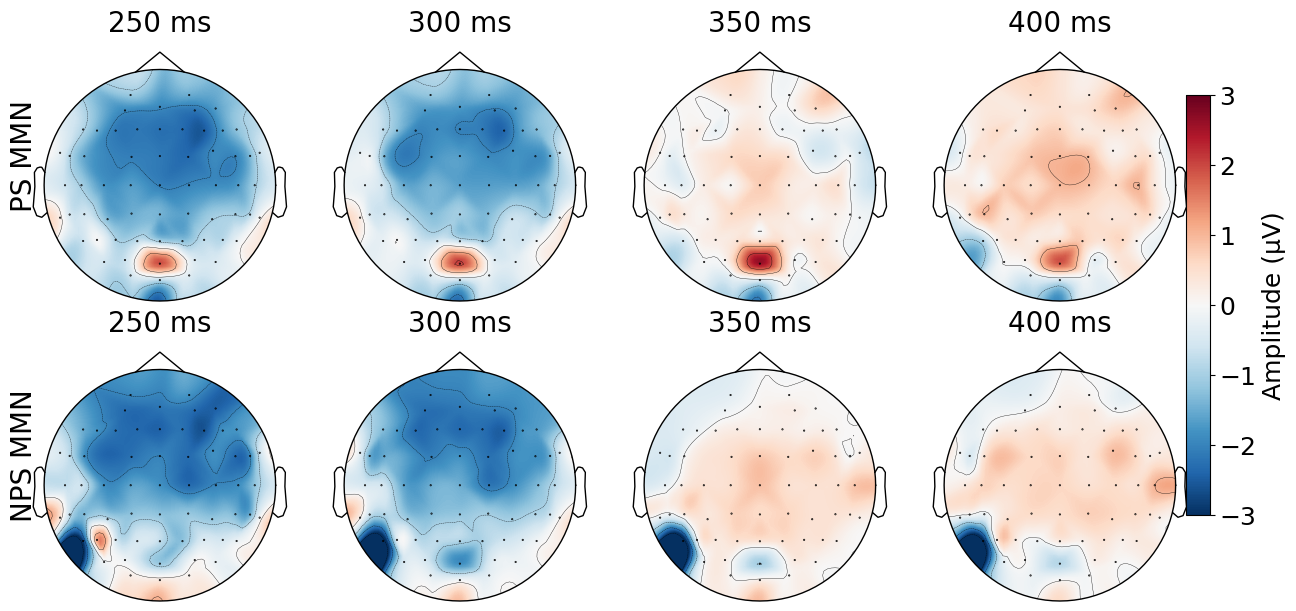

In [25]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [0.25, 0.30, 0.35, 0.40]

# Set the color scale range
vlim = (-3, 3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(2, len(time_points), figsize=(12, 6), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    Personal_MMN_erp.copy().drop_channels(["AF7", "FC3"]).plot_topomap(
        times=[time], axes=axes[0, i], colorbar=False, vlim=vlim, show=False
    )
    axes[0, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Plot topomaps for the second evoked (B1_MMN_erp)
for i, time in enumerate(time_points):
    im= non_sign_MMN_erp.copy().drop_channels(["AF7","FC3"]).plot_topomap(
        times=[time], axes=axes[1, i], colorbar=False, vlim=vlim, show=False
    )
    axes[1, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.02, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Amplitude (µV)')

# Add row labels
fig.text(0.0001, 0.75, 'PS MMN', fontsize=20, rotation=90, va='center')
fig.text(0.0001, 0.25, 'NPS MMN', fontsize=20, rotation=90, va='center')

plt.show()



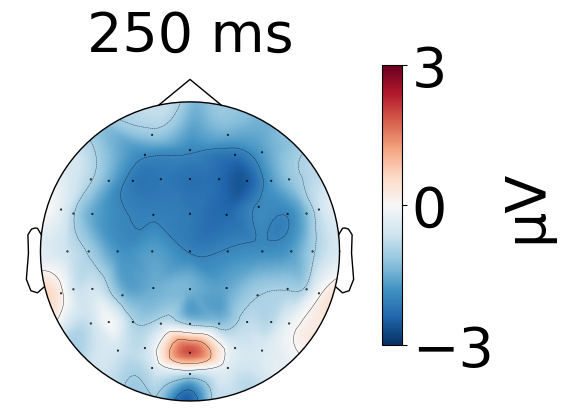

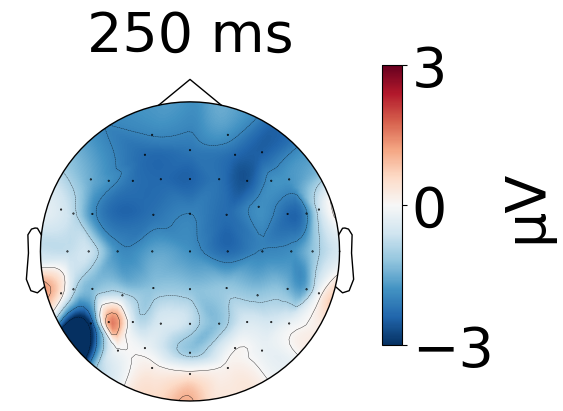

In [26]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [0.25]

# Set the color scale range
vlim = (-3, 3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    Personal_MMN_erp.copy().drop_channels(["AF7", "FC3"]).plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False
    )
    axes.set_title(f"{time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15, 0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40)  # Adjust fontsize here
cbar.set_ticks([-3, 0, 3])
# Add row labels
#fig.text(0.0001, 0.5, 'PS MMN', fontsize=28, rotation=90, va='center')


plt.show()
fig, axes = plt.subplots(1, len(time_points), figsize=(4, 4), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    non_sign_MMN_erp.copy().drop_channels(["AF7", "FC3"]).plot_topomap(
        times=[time], axes=axes, colorbar=False, vlim=vlim, show=False
    )
    axes.set_title(f"{time * 1000:.0f} ms",fontsize=40)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.98, 0.15,  0.05, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='')
cbar.ax.tick_params(labelsize=40)
# Set the font size of the colorbar label
cbar.set_label('µV', fontsize=40)  # Adjust fontsize here
cbar.set_ticks([-3, 0, 3])

# Add row labels
#fig.text(0.0001, 0.5, 'NPS MMN', fontsize=28, rotation=90, va='center')


plt.show()


### Statisicial test 

In [27]:
import numpy as np
from scipy import stats

# Assuming you have the averaged data for each event (from the previous code)
# For example, let's compare Event A and Event B
event_A_averages = B1_avg_stat['15']  # Replace with actual event name
event_B_averages = B2_avg_stat['25']  # Replace with actual event name

# Perform a t-test between the two sets of averaged data
t_stat, p_val = stats.ttest_ind(event_A_averages, event_B_averages, axis=0)

# Output the t-statistic and p-values for each channel
print("T-statistic:", t_stat)
print("P-values:", p_val)

T-statistic: [4.77451661]
P-values: [1.83187515e-06]


In [30]:
B1_avg_stat

{'14': array([[ 2.35488484e-06],
        [-6.66807348e-07],
        [-7.97333420e-07],
        ...,
        [-9.73137761e-06],
        [-1.42594903e-05],
        [ 1.35272930e-05]]),
 '15': array([[-1.93733152e-05],
        [ 1.96384325e-05],
        [-1.03497497e-05],
        ...,
        [-6.08600416e-06],
        [-9.40162927e-07],
        [ 1.30183893e-06]])}

### Block 3 


In [29]:
data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
CB_all_epochs_list =[]
B2_all_epochs_list =[]
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            events,event_dict = mne.events_from_annotations(raw)
            try:  
                epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25,35,34] ,tmin=-0.300, tmax=0.9500,
                                             baseline=(None, 0), reject_by_annotation=False,
                                             preload=True)
            except:
                continue
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            try:  
                epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25,35,34] ,tmin=-0.300, tmax=0.9500,
                                             baseline=(None, 0), reject_by_annotation=False,
                                             preload=True)
            except:
                continue
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[34,35] ,tmin=-0.300, tmax=0.9500,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            #print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels = [ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            
            print(f"After Bad epoch rejection,  number of epochs in Block   {len(cleaned_epochs['34','35'])} ")
            # Append the subject's epochs to the list
            """B1_sta_all_epochs_list.append(cleaned_epochs['14'])
            B1_devi_all_epochs_list.append(cleaned_epochs['1  5']) """
            CB_all_epochs_list.append(cleaned_epochs['34','35'])
            #B2_all_epochs_list.append(cleaned_epochs['24','25'])





CB_all_epochs = mne.concatenate_epochs(CB_all_epochs_list)


print(f"After Bad epoch rejection,  number of epochs in Block 1 standard {len(CB_all_epochs['34'])} and deviant {len(CB_all_epochs['35'])}")
CB_devi_eps = CB_all_epochs['35'].average()
CB_sta_eps = CB_all_epochs["34"].average()
CB_MMN_erp = mne.combine_evoked([ CB_devi_eps,CB_sta_eps], weights=[1,-1])
evokeds = dict(CB_MMN_erp =CB_MMN_erp, CB_devi_eps= CB_devi_eps,CB_sta_eps=CB_sta_eps)  
##  Statistical significance 
CB_avg_stat = Average_in_trials_in_time_window(CB_all_epochs,chan="Cz", stime=.430,etime = .530)
#picks = [n for n in range(1, 5)]
picks= ['F3', 'Fz', 'F4',]
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861"""


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Work_data\\Notification_evoked_response\\Data_at_IITD/bids_data\\EEG'

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11744\1357579818.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  CB_all_epochs = mne.concatenate_epochs(CB_all_epochs_list)


Not setting metadata
2427 matching events found
Applying baseline correction (mode: mean)
After Bad epoch rejection,  number of epochs in Block 1 standard 2029 and deviant 398
Event: 34, Averages shape: (2029, 1)
Event: 35, Averages shape: (398, 1)
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11744\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_11744\1263116742.py:12: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  trial_averages = np.mean(event_epochs.get_data(), axis=2)  # Average across time (axis=2)


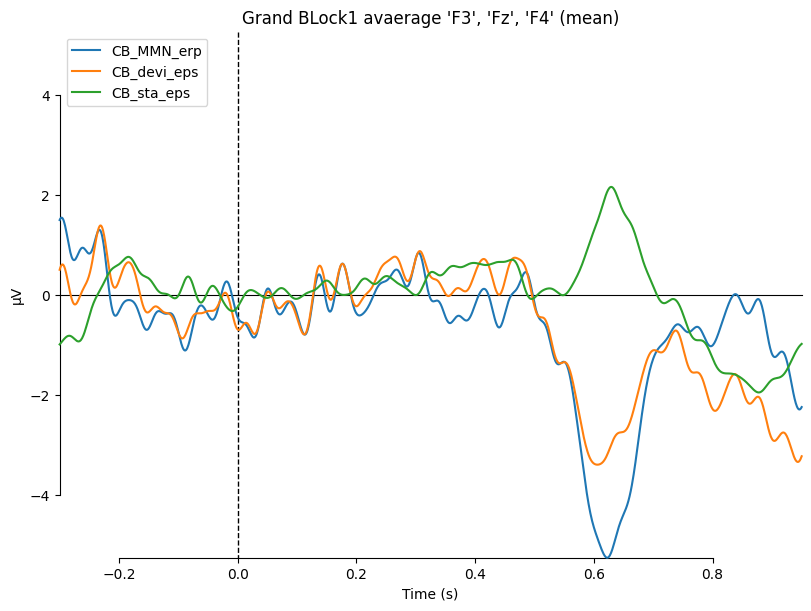

'After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861'

In [ ]:

CB_all_epochs = mne.concatenate_epochs(CB_all_epochs_list)


print(f"After Bad epoch rejection,  number of epochs in Block 1 standard {len(CB_all_epochs['34'])} and deviant {len(CB_all_epochs['35'])}")
CB_devi_eps = CB_all_epochs['35'].average()
CB_sta_eps = CB_all_epochs["34"].average()
CB_MMN_erp = mne.combine_evoked([ CB_devi_eps,CB_sta_eps], weights=[1,-1])
evokeds = dict(CB_MMN_erp =CB_MMN_erp, CB_devi_eps= CB_devi_eps,CB_sta_eps=CB_sta_eps)  
##  Statistical significance 
CB_avg_stat = Average_in_trials_in_time_window(CB_all_epochs,chan="Cz", stime=.430,etime = .530)
#picks = [n for n in range(1, 5)]
picks= ['F3', 'Fz', 'F4',]
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  =  "Grand BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")
"""After Bad epoch rejection,  number of epochs in Block 1 standard 14230 and deviant 2861"""